# Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import chi2_contingency

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Loading the Dataset


In [ ]:

df = pd.read_csv("/content/Mental Health Dataset.csv")   # update path if different

print("Shape:", df.shape)
df.head()

Shape: (292364, 17)


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


# Exploratory Data Analysis

# Dataset info

In [ ]:

df.info()

# Quick summary of numeric features
print("\nNumeric features summary:\n")
print(df.describe())

# Quick summary of categorical features (top 5 most frequent values each)
print("\nCategorical features sample:")
for col in df.select_dtypes(include=['object']).columns[:10]:  # show first 10 categorical columns
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

# Inspect the target variable

In [ ]:
# Step 3: Inspect the target variable
target = "Growing_Stress"   # corrected column name
assert target in df.columns, f"Target column '{target}' not found!"

print("Data type:", df[target].dtype)
print("Unique values:", df[target].unique())
print("\nValue counts:\n", df[target].value_counts(dropna=False))


Data type: object
Unique values: ['Yes' 'No' 'Maybe']

Value counts:
 Growing_Stress
Maybe    99985
Yes      99653
No       92726
Name: count, dtype: int64


# Check missing values in the dataset

In [ ]:

# Count of missing values per column
missing_counts = df.isnull().sum()

# Percentage of missing values per column
missing_percentage = (df.isnull().mean() * 100).round(2)

# Combine into one table for clarity
missing_table = pd.DataFrame({
    'Missing_Values': missing_counts,
    'Missing_%': missing_percentage
}).sort_values(by='Missing_%', ascending=False)

print("Missing values per column:")
display(missing_table.head(20))  # show top 20 columns with most missing


Missing values per column:


,Missing_Values,Missing_%
self_employed,5202,1.78
Timestamp,0,0.00
Gender,0,0.00
Country,0,0.00
Occupation,0,0.00
family_history,0,0.00
treatment,0,0.00
Days_Indoors,0,0.00
Growing_Stress,0,0.00
Changes_Habits,0,0.00


# Check for duplicate rows in the dataset

In [ ]:
# Step 5: Check for duplicate rows in the dataset

# Count total duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# Show duplicate rows (if you want to inspect them)
duplicate_rows = df[df.duplicated()]
display(duplicate_rows.head(20))  # display first 20 duplicate rows



Total duplicate rows: 2313


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
18271,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,31-60 days,No,No,Maybe,High,No,No,Maybe,No,Not sure
18272,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,31-60 days,No,No,Maybe,High,No,No,Maybe,No,No
18273,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,31-60 days,No,No,Maybe,High,No,No,Maybe,No,Yes
18274,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,31-60 days,No,No,Maybe,High,No,No,Maybe,Maybe,Yes
18275,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,31-60 days,No,No,Maybe,High,No,No,Maybe,No,Yes
18276,8/27/2014 11:49,Female,Poland,Corporate,No,No,Yes,31-60 days,No,No,Maybe,High,No,No,Maybe,Maybe,Not sure
18277,8/27/2014 11:51,Female,Australia,Corporate,No,Yes,Yes,31-60 days,No,No,Maybe,High,No,No,Maybe,No,Not sure
18278,8/27/2014 11:52,Female,United States,Corporate,No,No,No,31-60 days,No,No,Maybe,High,No,No,Maybe,No,No
18279,8/27/2014 12:18,Female,United States,Corporate,No,No,No,31-60 days,No,No,Maybe,High,No,No,Maybe,No,Not sure
18280,8/27/2014 12:37,Female,United States,Corporate,No,No,No,31-60 days,No,No,Maybe,High,No,No,Maybe,No,No


# Distributions of categorical features

Categorical features:
['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']


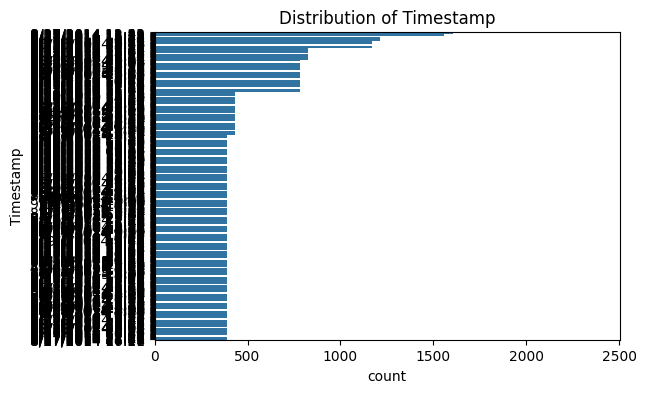

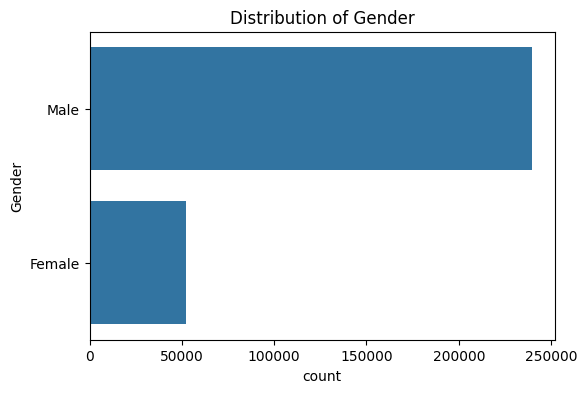

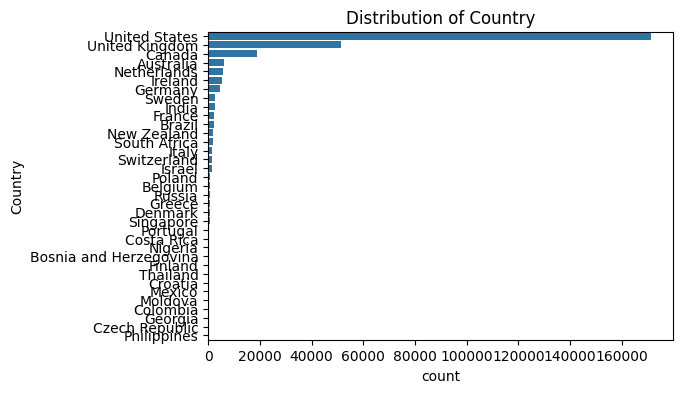

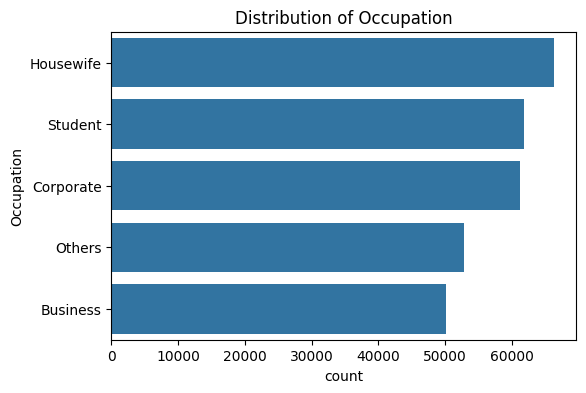

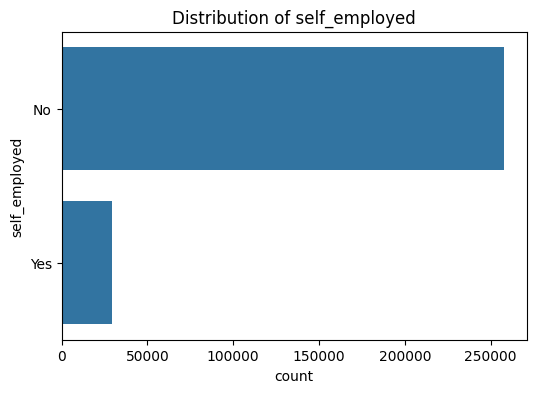

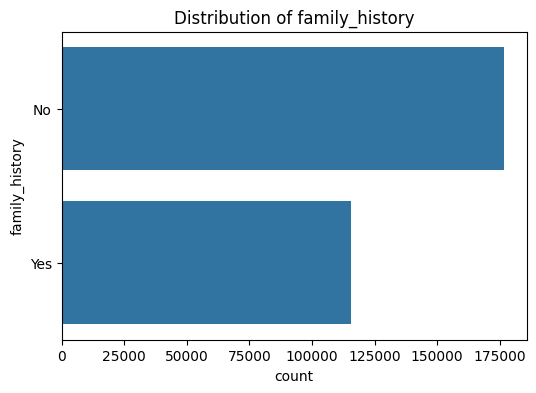

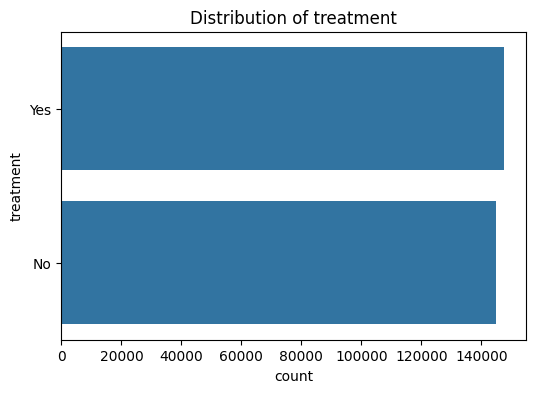

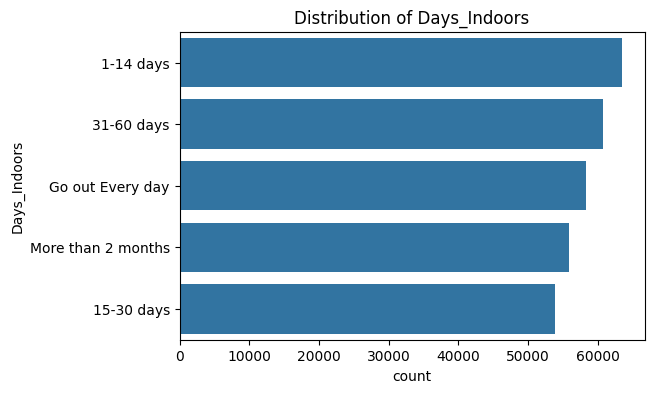

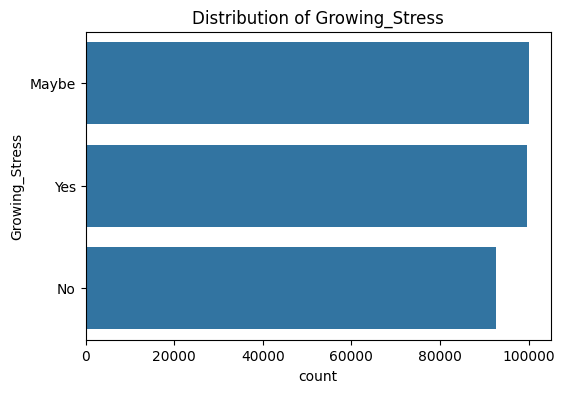

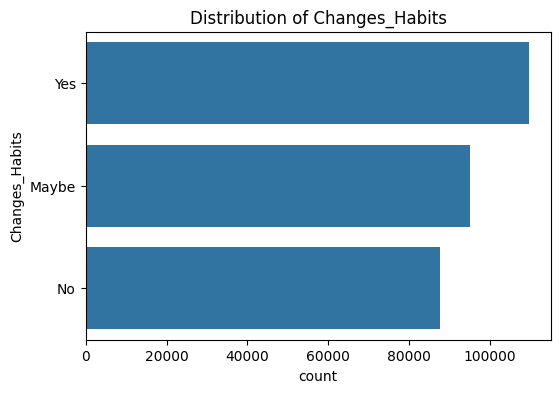

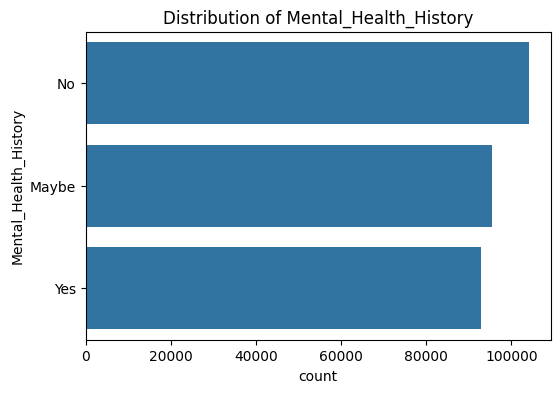

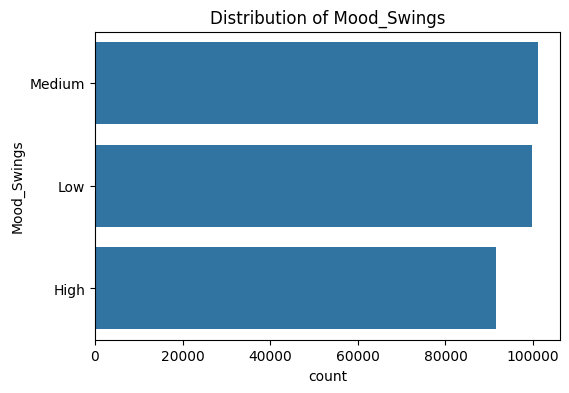

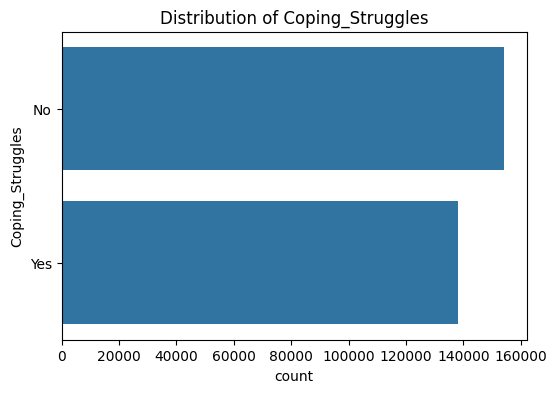

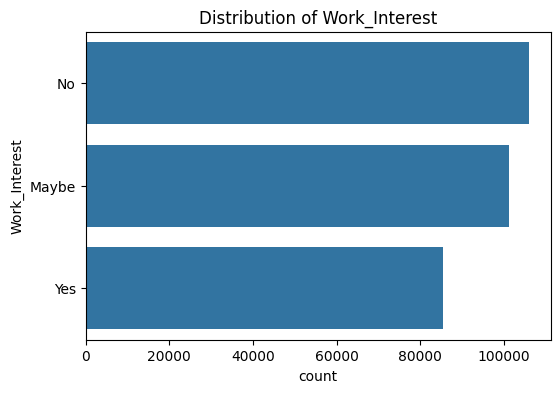

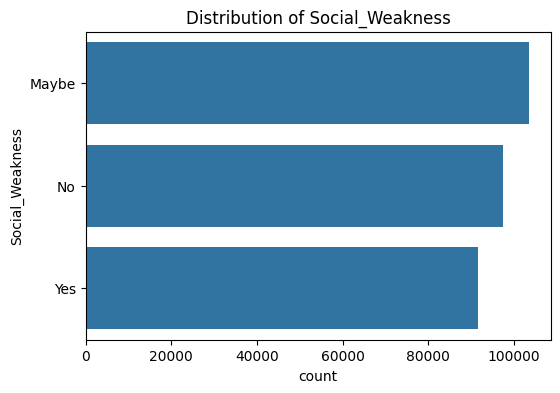

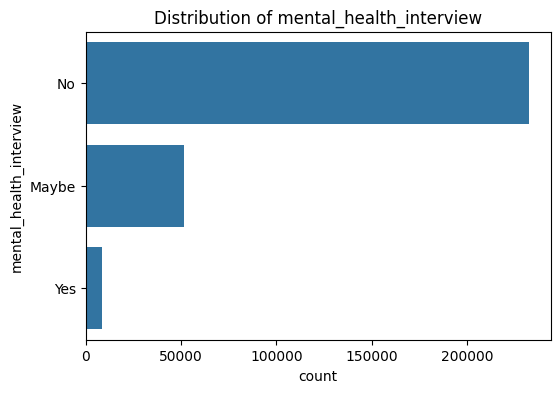

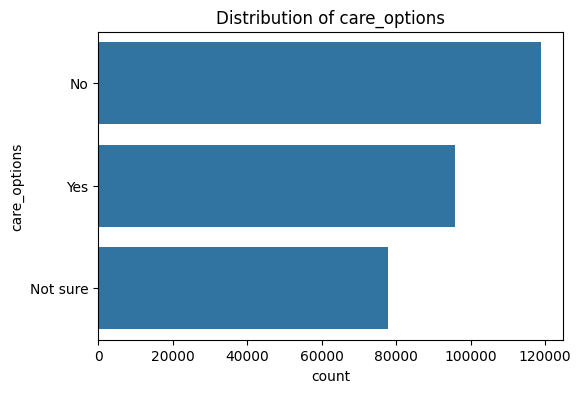

In [ ]:

# List all categorical columns
categorical_cols = df.columns
print("Categorical features:")
print(list(categorical_cols))

# Plot distributions of categorical features
import matplotlib.pyplot as plt
import seaborn as sns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()


# Class Distribution of Target Column

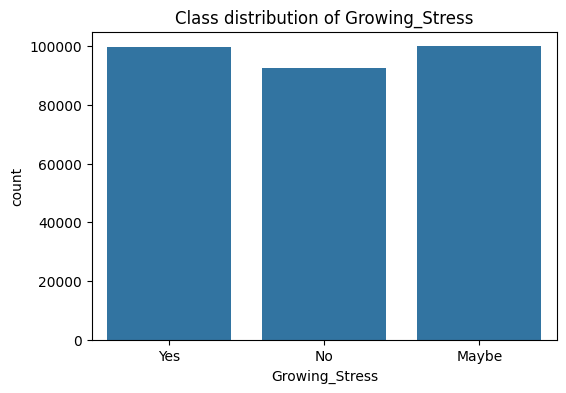

Class distribution (in %):
Growing_Stress
Maybe    34.198807
Yes      34.085250
No       31.715943
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target column
target_col = 'Growing_Stress'

# Distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title(f"Class distribution of {target_col}")
plt.show()

# Percentages
print("Class distribution (in %):")
print(df[target_col].value_counts(normalize=True) * 100)


# Understanding relationships between features and target

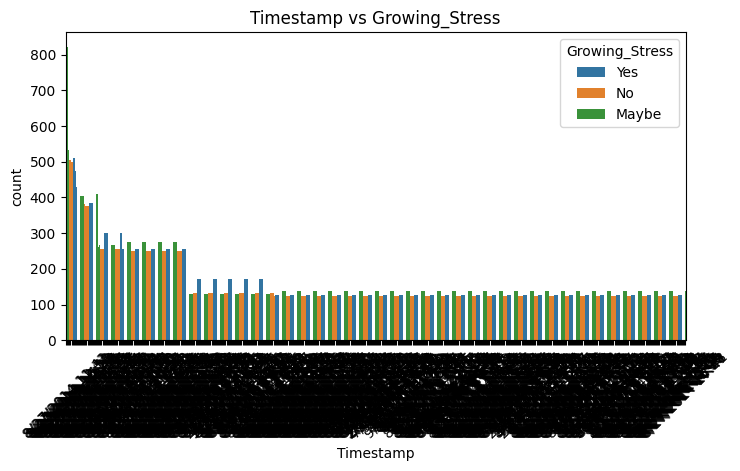

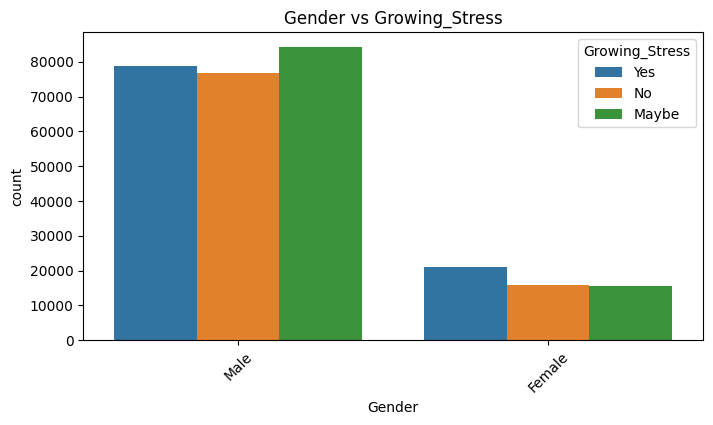

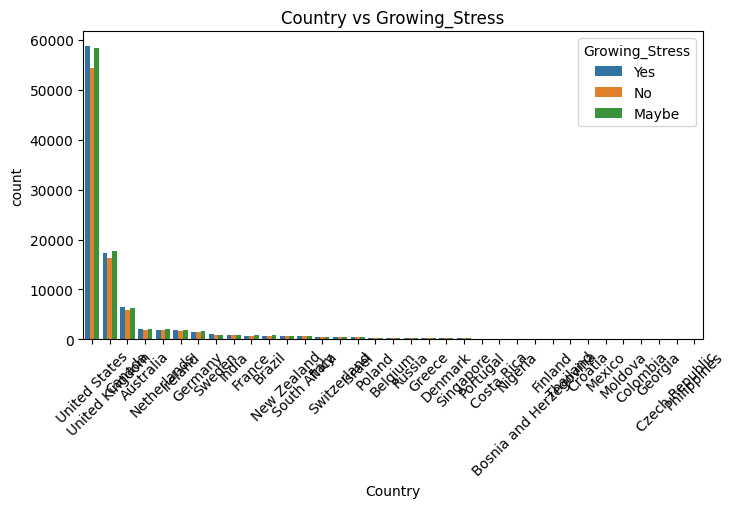

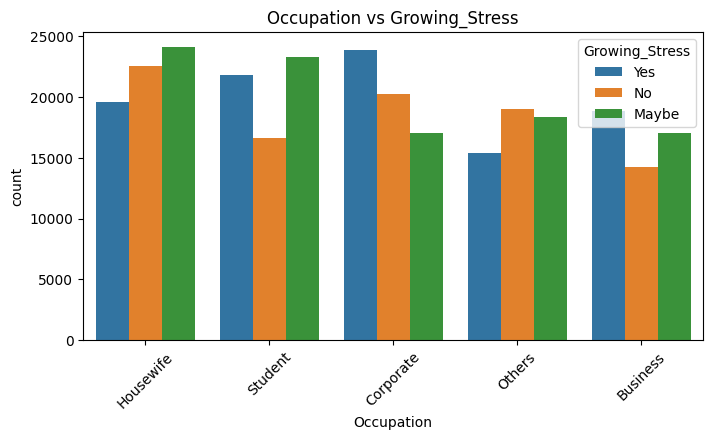

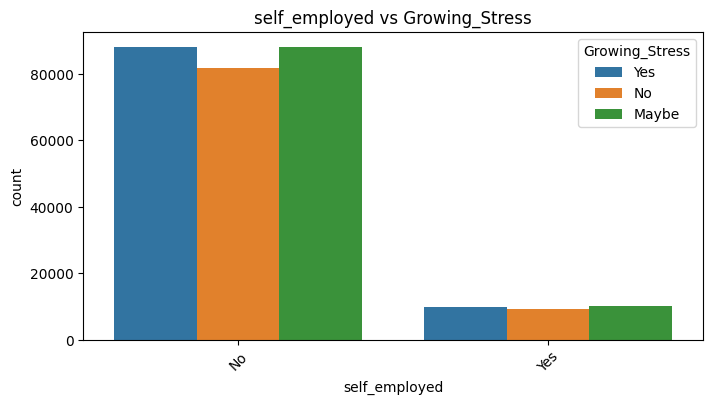

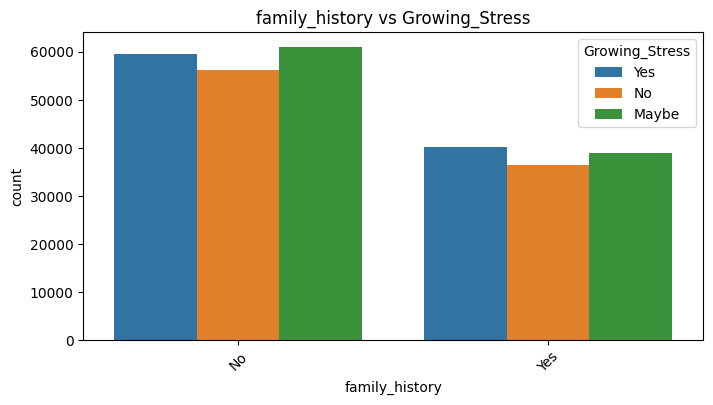

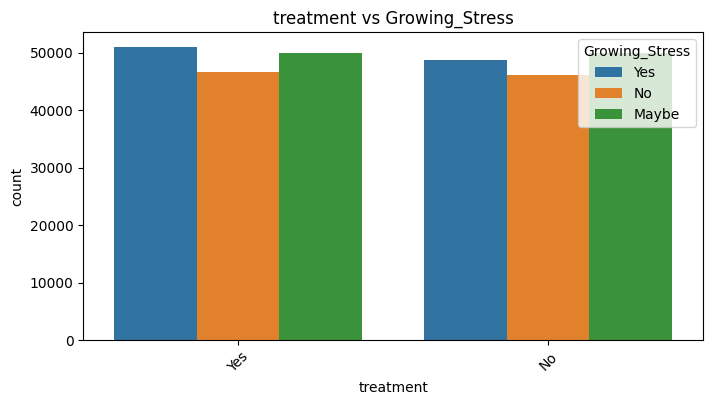

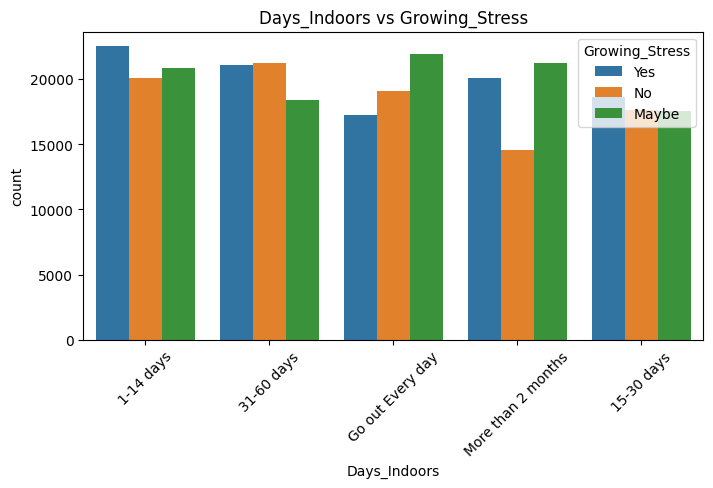

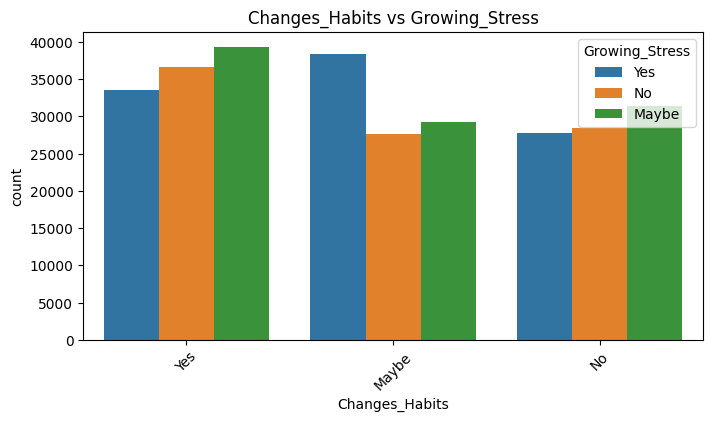

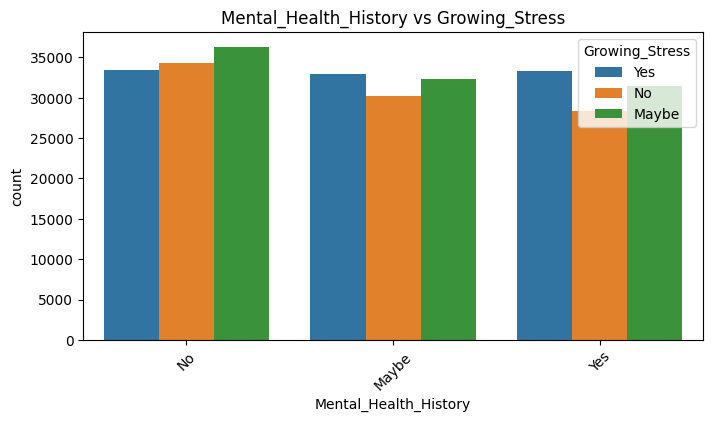

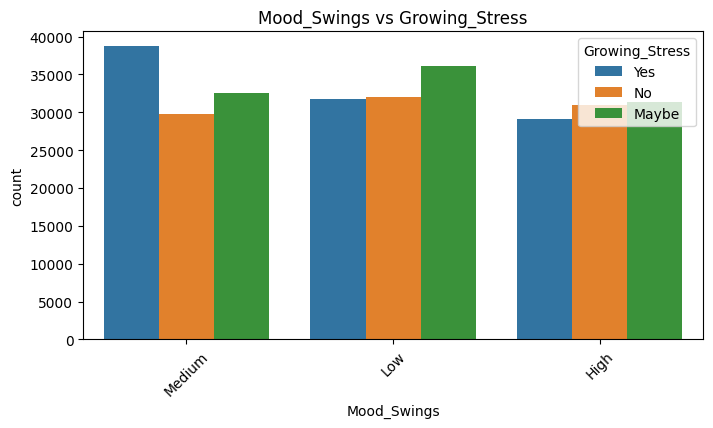

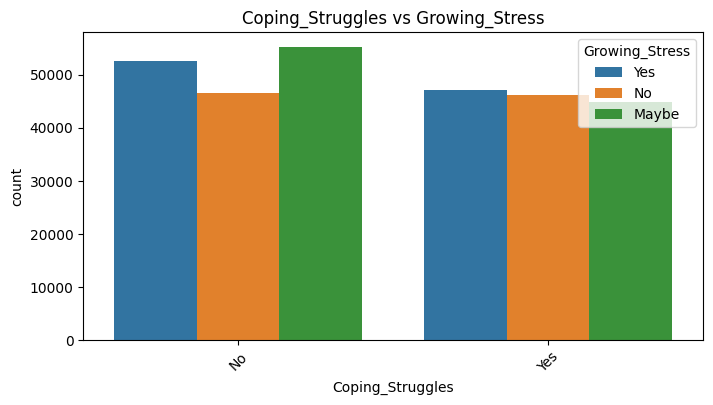

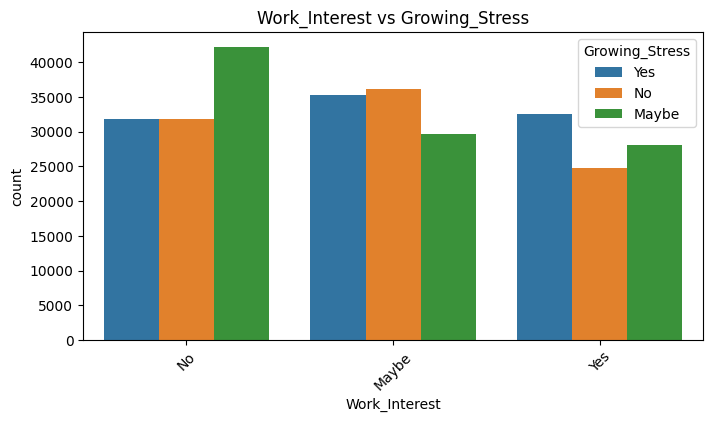

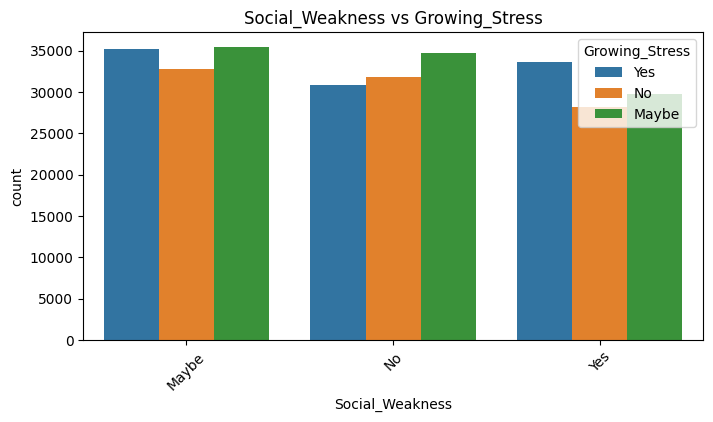

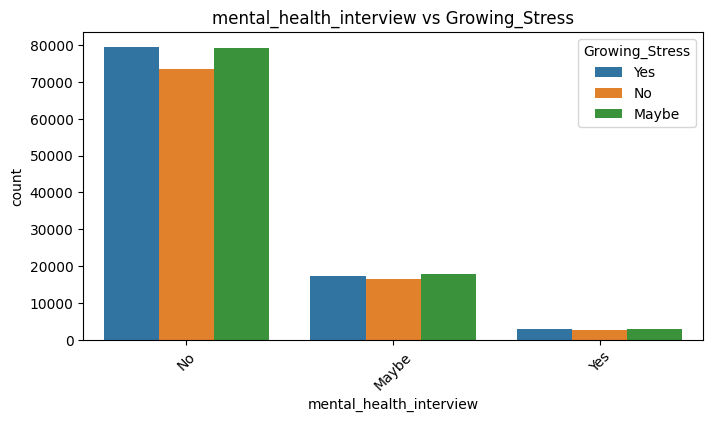

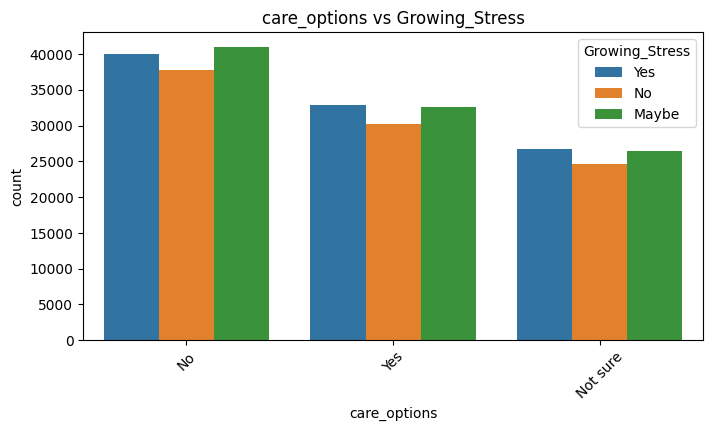

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

target_col = 'Growing_Stress'
categorical_cols = [col for col in df.columns if col != target_col]

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue=target_col, data=df, order=df[col].value_counts().index)
    plt.title(f"{col} vs {target_col}")
    plt.xticks(rotation=45)
    plt.show()


# Data Preprocessing

# Handling Missing Values

In [ ]:
df.fillna({'self_employed': df['self_employed'].mode()[0]}, inplace=True)


# Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
categorical_cols = df_encoded.columns

# Encode all categorical features
for col in categorical_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))


# Correlation of features

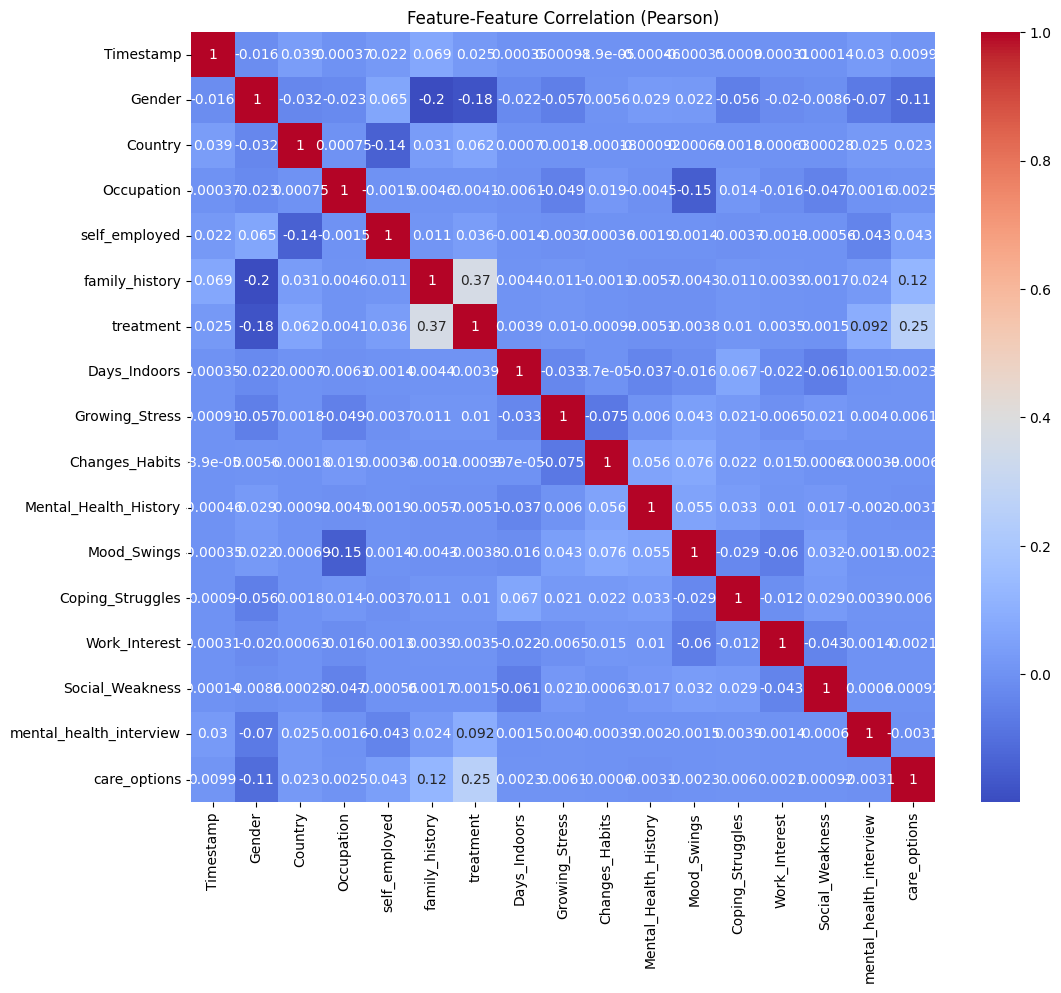

Correlation of features with target:
Growing_Stress             1.000000
Mood_Swings                0.043442
Coping_Struggles           0.021447
Social_Weakness            0.020651
family_history             0.011305
treatment                  0.010056
care_options               0.006068
Mental_Health_History      0.006015
mental_health_interview    0.003974
Country                    0.001818
Timestamp                  0.000906
self_employed             -0.003714
Work_Interest             -0.006534
Days_Indoors              -0.033096
Occupation                -0.049321
Gender                    -0.056746
Changes_Habits            -0.074513
Name: Growing_Stress, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

target_col = 'Growing_Stress'

# --- Step 1: Feature-Feature Correlation (Pearson) ---
plt.figure(figsize=(12,10))
feature_corr = df_encoded.corr()
sns.heatmap(feature_corr, annot=True, cmap="coolwarm")
plt.title("Feature-Feature Correlation (Pearson)")
plt.show()

# --- Optional: Correlation of features with target ---
target_corr = feature_corr[target_col].sort_values(ascending=False)
print("Correlation of features with target:")
print(target_corr)


# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_encoded.drop(columns=['Growing_Stress'])
y = df_encoded['Growing_Stress']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Random Forest

Random Forest Accuracy: 0.9829322935371881
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19997
           1       0.99      0.99      0.99     18545
           2       0.97      0.98      0.97     19931

    accuracy                           0.98     58473
   macro avg       0.98      0.98      0.98     58473
weighted avg       0.98      0.98      0.98     58473



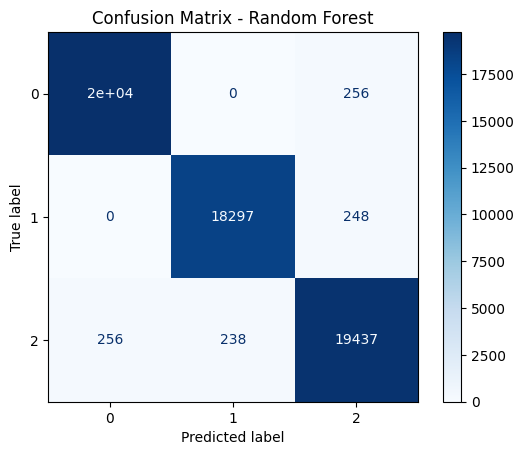

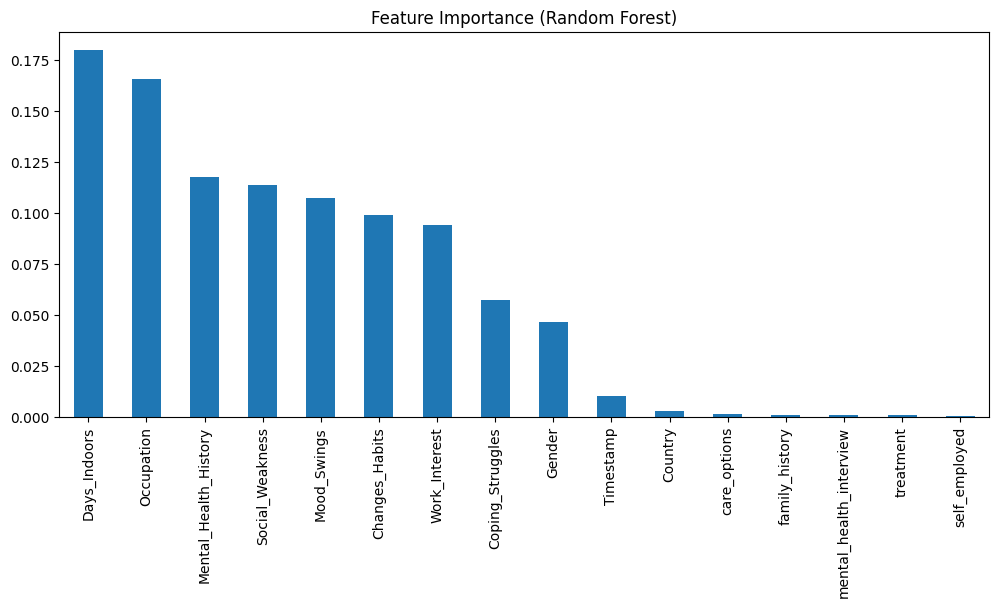

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(12,5), title='Feature Importance (Random Forest)')
plt.show()



# Decision Tree

Decision Tree Accuracy: 0.9829322935371881
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19997
           1       0.99      0.99      0.99     18545
           2       0.98      0.97      0.97     19931

    accuracy                           0.98     58473
   macro avg       0.98      0.98      0.98     58473
weighted avg       0.98      0.98      0.98     58473



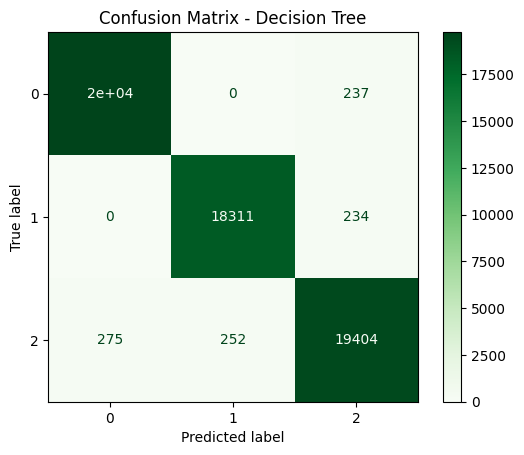

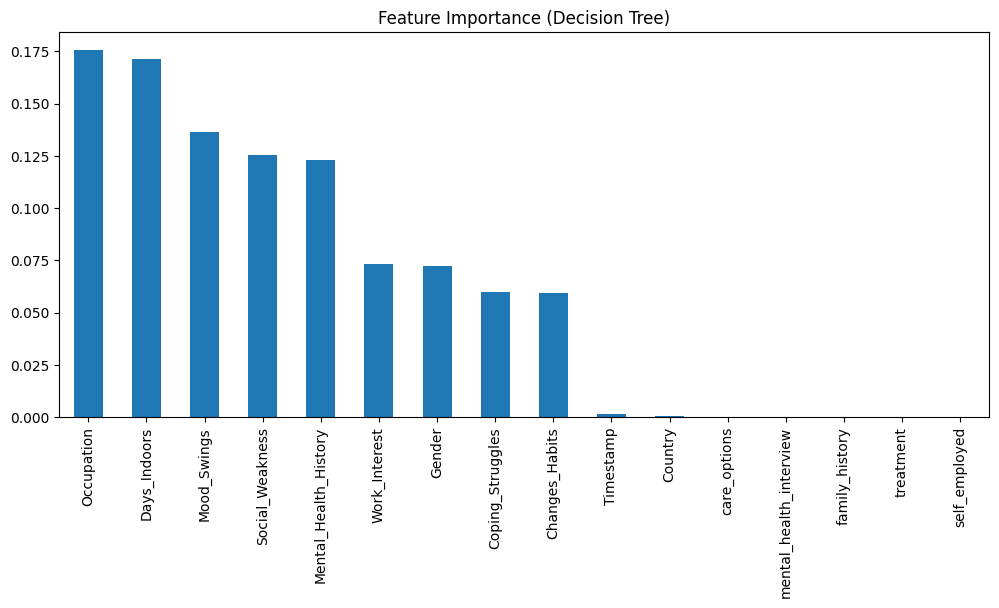

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation metrics
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_model.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# Feature importance for Decision Tree
dt_importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
dt_importances.plot(kind='bar', figsize=(12,5), title='Feature Importance (Decision Tree)')
plt.show()


# PCA ( Principal Component Analysis )

In [ ]:
from sklearn.decomposition import PCA

# use fewer components, e.g., 10 (must be <=16)
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train_scaled.shape[1])
print("Reduced features:", X_train_pca.shape[1])


Original features: 16
Reduced features: 10


# KNN

KNN Accuracy (with PCA): 0.9453422947343219
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     19997
           1       0.95      0.95      0.95     18545
           2       0.94      0.94      0.94     19931

    accuracy                           0.95     58473
   macro avg       0.95      0.95      0.95     58473
weighted avg       0.95      0.95      0.95     58473



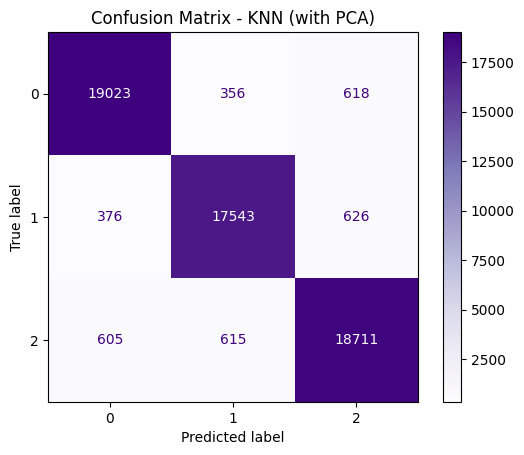

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train KNN with PCA-transformed data
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_model.fit(X_train_pca, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_pca)

# Evaluation metrics
print("KNN Accuracy (with PCA):", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)
disp.plot(cmap=plt.cm.Purples)
plt.title("Confusion Matrix - KNN (with PCA)")
plt.show()


# XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:54:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9841465291673079
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19997
           1       0.99      0.99      0.99     18545
           2       0.98      0.98      0.98     19931

    accuracy                           0.98     58473
   macro avg       0.98      0.98      0.98     58473
weighted avg       0.98      0.98      0.98     58473



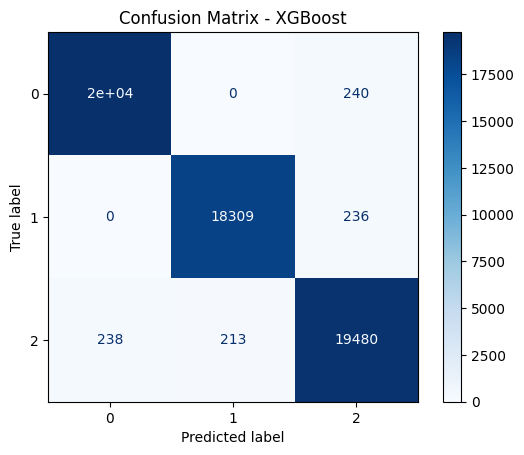

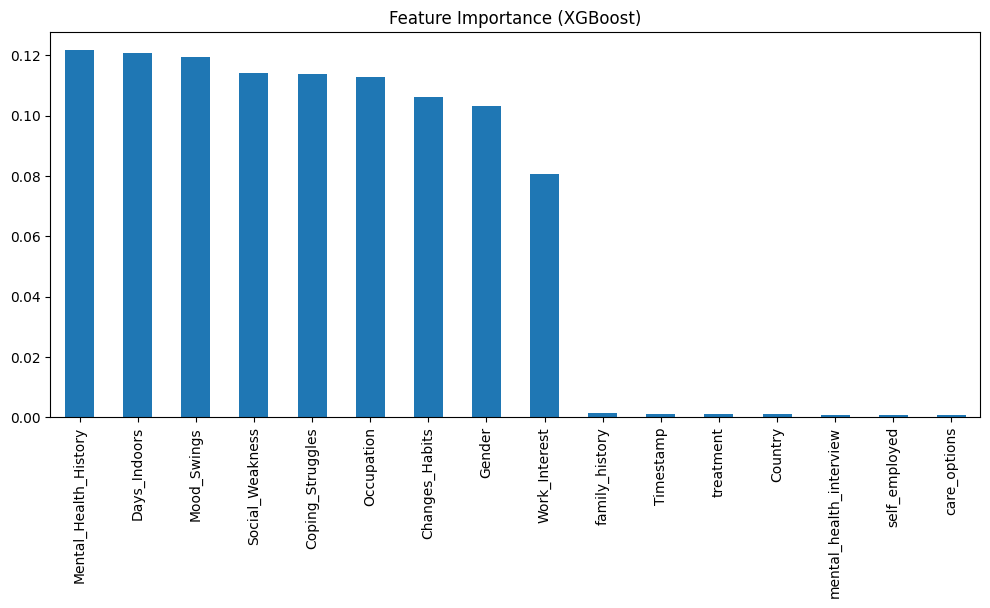

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# ---------------- XGBoost ----------------
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="mlogloss"
)
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Evaluation metrics
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - XGBoost")
plt.show()

# Feature importance
xgb_importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
xgb_importances.plot(kind='bar', figsize=(12,5), title='Feature Importance (XGBoost)')
plt.show()


# CatBoost

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.3 MB/s eta 0:00:00


0:	learn: 0.5089935	total: 194ms	remaining: 1m 36s
100:	learn: 0.9604474	total: 19.4s	remaining: 1m 16s
200:	learn: 0.9857840	total: 32.2s	remaining: 47.9s
300:	learn: 0.9903374	total: 42.1s	remaining: 27.8s
400:	learn: 0.9903716	total: 50.7s	remaining: 12.5s
499:	learn: 0.9906153	total: 59s	remaining: 0us
CatBoost Accuracy: 0.9892600003420382

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     19997
           1       1.00      0.99      0.99     18545
           2       0.98      0.99      0.98     19931

    accuracy                           0.99     58473
   macro avg       0.99      0.99      0.99     58473
weighted avg       0.99      0.99      0.99     58473



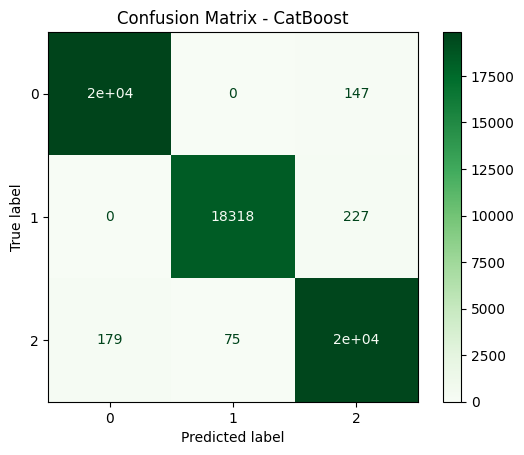

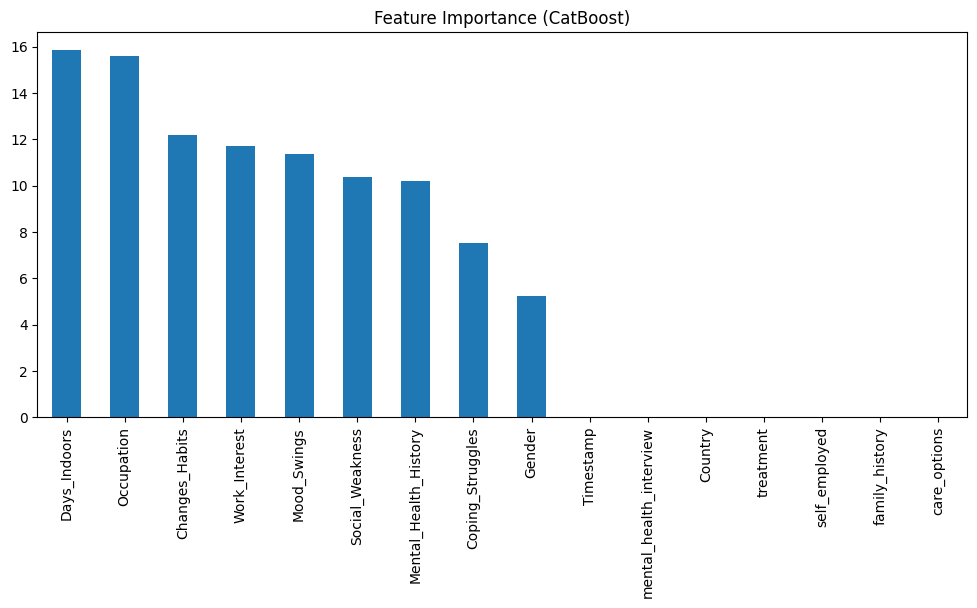

In [ ]:

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# ---------------- CatBoost Pipeline ----------------
# Initialize and train model
cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100
)
cat.fit(X_train, y_train)

# Predictions
y_pred_cat = cat.predict(X_test)

# Evaluation metrics
print("CatBoost Accuracy:", accuracy_score(y_test, y_pred_cat))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cat))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_cat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cat.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - CatBoost")
plt.show()

# Feature Importance
cat_importances = pd.Series(cat.feature_importances_, index=X.columns).sort_values(ascending=False)
cat_importances.plot(kind='bar', figsize=(12,5), title='Feature Importance (CatBoost)')
plt.show()


            Model  Accuracy
0   Random Forest     0.983
1   Decision Tree     0.983
2  KNN (with PCA)     0.945
3         XGBoost     0.984
4        CatBoost     0.989


/tmp/ipython-input-1509781520.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=df_models, palette='viridis')


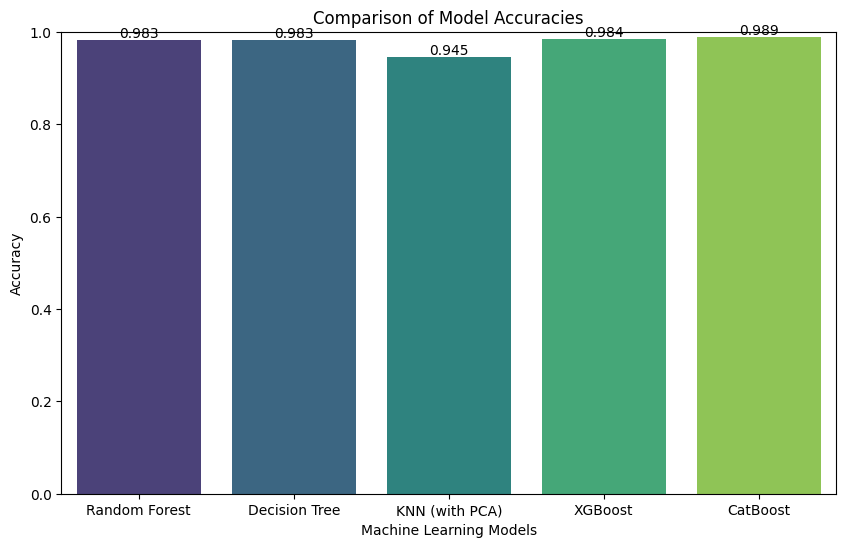

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model comparison data
model_data = {
    'Model': ['Random Forest', 'Decision Tree', 'KNN (with PCA)', 'XGBoost', 'CatBoost'],
    'Accuracy': [0.983, 0.983, 0.945, 0.984, 0.989]
}

# Create DataFrame
df_models = pd.DataFrame(model_data)

# --- Display table ---
print(df_models)

# --- Bar plot ---
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Accuracy', data=df_models, palette='viridis')
plt.ylim(0,1)
plt.title("Comparison of Model Accuracies")
plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Models")
for index, value in enumerate(df_models['Accuracy']):
    plt.text(index, value + 0.005, f"{value:.3f}", ha='center')
plt.show()


# Pairwise Hypothesis Testing

/tmp/ipython-input-2065693598.py:75: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  significance_matrix.replace({"Significant":1, "Not Significant":0, "-":np.nan}),


--- Pairwise McNemar Tests ---
        Model 1       Model 2  p-value     Significance
0  RandomForest  DecisionTree      1.0  Not Significant
1  RandomForest           KNN      0.0      Significant
2  RandomForest       XGBoost      0.0      Significant
3  RandomForest      CatBoost      0.0      Significant
4  DecisionTree           KNN      0.0      Significant
5  DecisionTree       XGBoost      0.0      Significant
6  DecisionTree      CatBoost      0.0      Significant
7           KNN       XGBoost      0.0      Significant
8           KNN      CatBoost      0.0      Significant
9       XGBoost      CatBoost      0.0      Significant


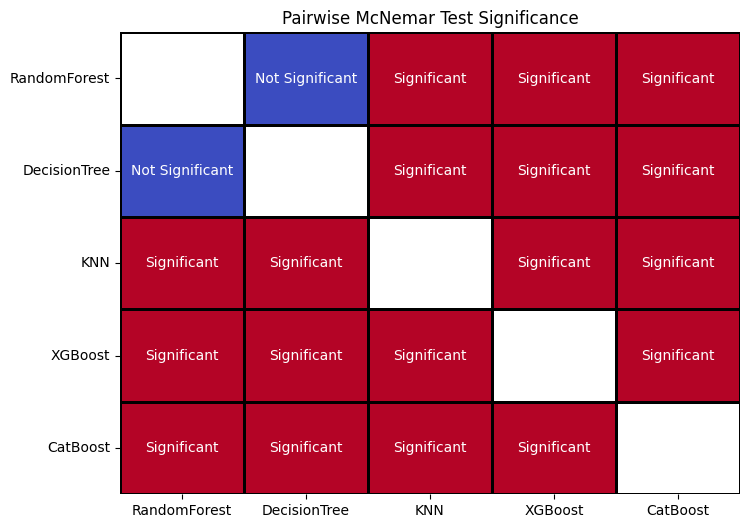

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar
import seaborn as sns
import matplotlib.pyplot as plt

# --- Ensure y_test is 1D ---
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.values.ravel()
elif isinstance(y_test, np.ndarray) and y_test.ndim > 1:
    y_test = y_test.ravel()

# --- Ensure all predictions are 1D ---
predictions = {
    "RandomForest": y_pred_rf,
    "DecisionTree": y_pred_dt,
    "KNN": y_pred_knn,
    "XGBoost": y_pred_xgb,
    "CatBoost": y_pred_cat
}

for key in predictions:
    pred = predictions[key]
    if isinstance(pred, pd.DataFrame):
        predictions[key] = pred.values.ravel()
    elif isinstance(pred, np.ndarray) and pred.ndim > 1:
        predictions[key] = pred.ravel()

models = list(predictions.keys())
results = []

# --- Pairwise McNemar tests ---
for i in range(len(models)):
    for j in range(i+1, len(models)):
        model1 = models[i]
        model2 = models[j]
        y_pred1 = predictions[model1]
        y_pred2 = predictions[model2]

        # Contingency table
        b = np.sum((y_pred1 == y_test) & (y_pred2 != y_test))
        c = np.sum((y_pred1 != y_test) & (y_pred2 == y_test))
        table = [[0, b], [c, 0]]

        # McNemar test
        result = mcnemar(table, exact=True)
        significance = "Significant" if result.pvalue < 0.05 else "Not Significant"

        results.append({
            "Model 1": model1,
            "Model 2": model2,
            "p-value": round(result.pvalue, 4),
            "Significance": significance
        })

# Convert to DataFrame
mcnemar_df = pd.DataFrame(results)
print("--- Pairwise McNemar Tests ---")
print(mcnemar_df)

# --- Heatmap Visualization ---
significance_matrix = pd.DataFrame(index=models, columns=models, data="")

for _, row in mcnemar_df.iterrows():
    significance_matrix.loc[row["Model 1"], row["Model 2"]] = row["Significance"]
    significance_matrix.loc[row["Model 2"], row["Model 1"]] = row["Significance"]

# Fill diagonal with "-"
for model in models:
    significance_matrix.loc[model, model] = "-"

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    significance_matrix.replace({"Significant":1, "Not Significant":0, "-":np.nan}),
    annot=significance_matrix,
    fmt='',
    cmap="coolwarm",
    cbar=False,
    linewidths=1,
    linecolor='black'
)
plt.title("Pairwise McNemar Test Significance")
plt.show()
